## Code for plotting CPC gif animation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, beta, uniform
import sys


def constrain_likelihoods(
    likelihoods_mat,  ## 2-D np array, shape (*, n_prop); flexible length, equal to n_models total from safe model to curr
    betas,  ## 1-D np array of lik-ratio bounds
    psis,  ## 1-D np array of normalization constants
):
    n_models, n_prop = np.shape(likelihoods_mat)

    constrained_likelihoods_mat = np.zeros((n_models, n_prop))

    ## First row of likelihoods_mat should already be safe/constrained
    constrained_likelihoods_mat[0] = likelihoods_mat[0]

    ## Compute constrained likelihoods for each subsequent policy and bound
    for i in range(1, n_models):
        constrained_likelihoods_mat[i] = np.where(
            likelihoods_mat[i] / constrained_likelihoods_mat[i - 1] < betas[i],
            likelihoods_mat[i] / psis[i],
            betas[i] * constrained_likelihoods_mat[i - 1] / psis[i],
        )

    return constrained_likelihoods_mat


def iwmci_prop_est(
    LRs_unconstrained_over_safe,  ## 1D numpy array
    unconstrained_liks,
    safe_liks,
    beta_t,  ## float
    psi_t,
    proposal: str = "safe",
):
    if proposal == "unconstrained":
        ## If beta_t >= 1: Assume proposal is unconstrained
        return np.mean(
            np.minimum(
                np.minimum(beta_t * safe_liks, unconstrained_liks) / psi_t,
                unconstrained_liks,
            )
            / unconstrained_liks
        )

    elif proposal == "safe":
        ## Else, beta_t < 1: Assume proposal is safe
        return np.mean(
            np.minimum(
                np.minimum(beta_t * safe_liks, unconstrained_liks) / psi_t, safe_liks
            )
            / safe_liks
        )

    else:
        raise ValueError(f"Unrecognized proposal name : {proposal}")

Beta : 1e-100
True Norm Const : 9.694189323028568e-101
num_proposals : 0
n_target : 5000


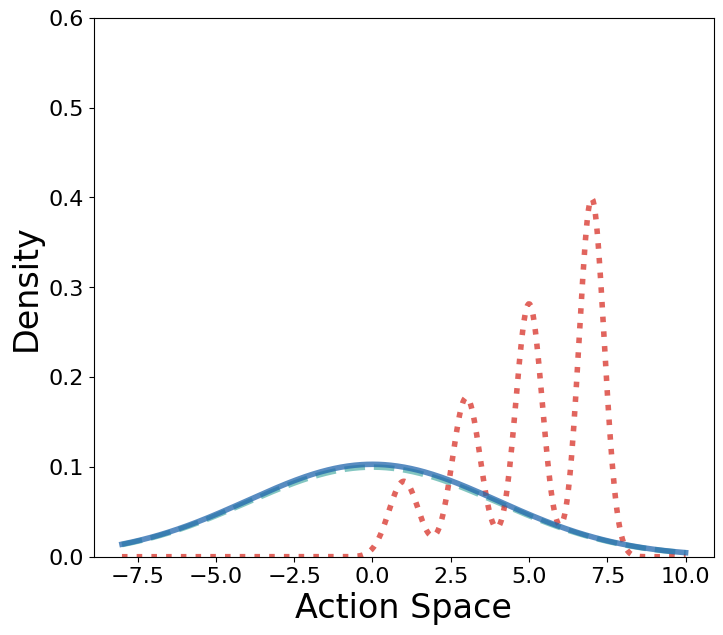

Beta : 1
True Norm Const : 0.3599456709990028
num_proposals : 0
n_target : 5000


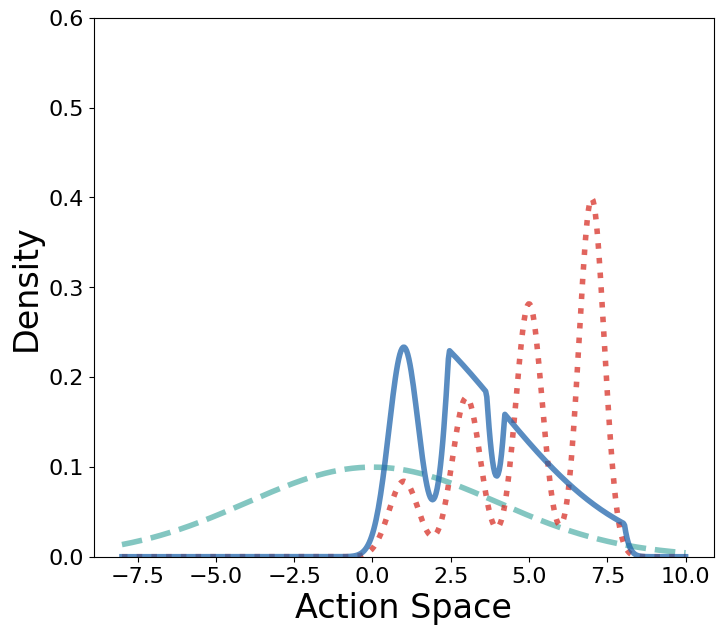

Beta : 10
True Norm Const : 0.8943819190201175
num_proposals : 0
n_target : 5000


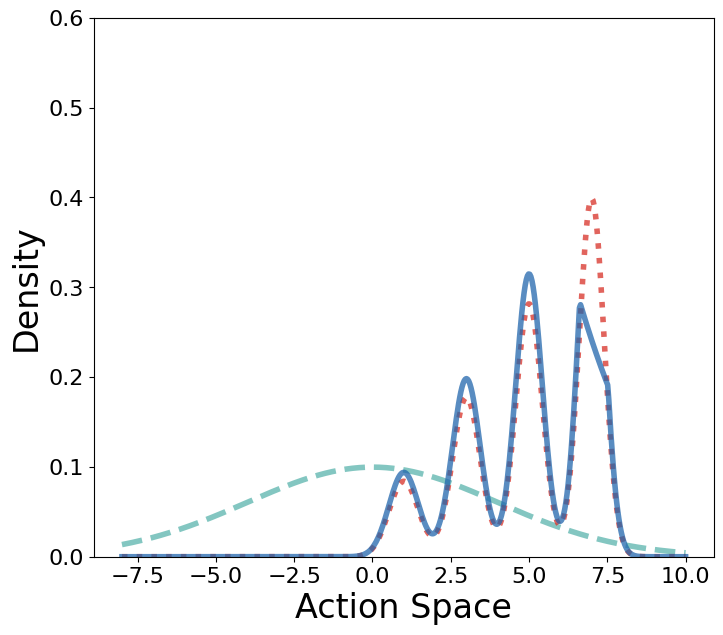

In [2]:
x_values = np.linspace(-8, 10, 500)  # For plotting the curve

BLUE = '#2166ac'           # β̂ vertical line
TEAL = '#5ab4ac'           # Calibration data (complements blue/red)
RED = '#d73027'            # Test point (conservative/warning)


## Safe policy
m0 = 0
s0 = 4

num_proposals = 0

def pdf0(x):
    return norm.pdf(x, loc=m0, scale=s0)


def draw_safe_samples(m0, s0, n_samples, random_state=0):
    return norm.rvs(loc=m0, scale=s0, size=n_samples, random_state=random_state)


pdf0_values = pdf0(x_values)

## Optimized policy
m1 = 1
s1 = 0.5

def pdf1(x, num_peaks=4):
    # w = 1/num_peaks ## mixture weight for each component
    w_ = np.arange(1, num_peaks+1)
    w = w_ / np.sum(w_)
    for p in range(num_peaks):
        if p == 0:
            pdf = w[p] * norm.pdf(x, loc=m1, scale=s1 * (1-w[p]/2)) 
        else:
            pdf += w[p] * norm.pdf(x, loc=m1 + 2*p, scale=s1 * (1-w[p]/2))
    
    return pdf


pdf1_values = pdf1(x_values)      


def draw_optimized_samples(m1, s1, n_samples, num_peaks=4):
    ## Sampling from optimized policy (it's a mixture)
    unifs = uniform.rvs(size=n_samples)
    optimized_samples = np.zeros(n_samples)
    # w = 1/num_peaks ## mixture weight for each component
    w_ = np.arange(1, num_peaks+1)
    w = w_ / np.sum(w_)
    for i, u in enumerate(unifs):
        for p in range(num_peaks):
            if u <= sum(w[:p+1]):
                optimized_samples[i] = norm.rvs(loc=m1 + 2 * p, scale=s1 * (1-w[p]/2))
                break
    
    return optimized_samples

## Lik ratios
lik_ratios = pdf1_values / pdf0_values


betas = [1e-100, 1, 10]

## Num target samples
n_target = 5000


for i, beta in enumerate(betas):
    pdf1_constrained_values = np.where(
        lik_ratios < beta, pdf1_values, beta * pdf0_values
    )  ## Constrained PDF (unnormalized)
    x_constraint_solution_ = np.where(
        lik_ratios < beta, True, False
    )  ## For determining piecewise condition

    if np.sum(x_constraint_solution_) == len(x_constraint_solution_):
        ## If True everywhere:
        idx_x_left = -1
        idx_x_right = -1

    else:
        idx_x_left = np.argmin(x_constraint_solution_)
        idx_x_right = (
            x_constraint_solution_.size - np.argmin(x_constraint_solution_[::-1]) - 1
        )

    x_constraint_solution = x_values[np.sum(x_constraint_solution_) - 1]
    if i == len(betas) - 1:
        ## Unconstrained case
        x_constraint_solution = -4

    norm_const_est_vals = []
    safe_norm_const_est_vals = []
    lr_ratio_vals = []
    unconstrained_liks = []
    safe_liks = []



    ## Array of LRs and likelihoods
    lr_ratio_vals_arr = np.array(lr_ratio_vals)
    unconstrained_liks_arr = np.array(unconstrained_liks)
    safe_liks_arr = np.array(safe_liks)



    norm_const = (
        (
            np.sum(pdf1_constrained_values)
            * (np.max(x_values) - np.min(x_values))
            / len(x_values)
        )
        if beta < np.inf
        else 1.0
    )

    print(f"Beta : {beta}")

    print(f"True Norm Const : {norm_const}")
    # print(f"Norm Const Est : {norm_const_est}")
    # print(f"Overlap Coefficient Est (1-TV dist est) : {intersect_norm_const_est}")

    print(f"num_proposals : {num_proposals}")
    print(f"n_target : {n_target}")

    liks_mat = np.vstack((pdf0_values, pdf1_values))
    betas_curr = np.array([None, beta])
    psis_curr = np.array([None, norm_const])
    constrained_liks = constrain_likelihoods(liks_mat, betas_curr, psis_curr)
    pdf1_constrained_values_normalized = constrained_liks[-1]

    plt.figure(figsize=(8, 7))

    # if beta < max(betas):
    #     plt.axvspan(
    #         xmin=x_values[idx_x_left], xmax=x_values[idx_x_right], alpha=0.1, color="C2"
    #     )

    plt.plot(x_values, pdf0_values, label="Safe Policy", color=TEAL, linewidth=4, 
             linestyle="--", alpha=0.75)
    plt.plot(
        x_values, pdf1_values, label="Optimized Policy", color=RED, linewidth=4, 
        linestyle=":", alpha=0.75
    )
    plt.plot(
        x_values,
        pdf1_constrained_values_normalized,
        label="Constrained Policy",
        color=BLUE,
        alpha=0.75,
        linewidth=4,
    )


    plt.xlabel("Action Space", fontsize=24)
    plt.ylabel("Density", fontsize=24)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.ylim([0, 0.6])
    # plt.legend(loc=[0, 1.12], ncols=2, fontsize=14)
    plt.savefig(
        f"./constrained_ex_beta{betas[i]:2e}.pdf",
        dpi=200,
        bbox_inches="tight",
        pad_inches=0.0,
    )
    plt.show()

In [3]:
n = 1000
num_betas = 100
safe_samples = draw_safe_samples(m0, s0, n_samples=n)
# safe_samples = draw_safe_samples(n_samples=n)

# infeasible_region
safe_samples_infeasible = np.where((safe_samples > 2) & (safe_samples < 4) 
                                    | (safe_samples > 6.5), True, False)
# safe_samples_infeasible = np.where((np.abs(safe_samples) > 0) & (np.abs(safe_samples) < 5), True, False)
# safe_samples_infeasible = np.where(safe_samples < 0, 1, 0)



optimized_samples = draw_optimized_samples(m1, s1, n_samples=n)
optimized_samples_infeasible = np.where(np.sin(safe_samples) > 0, True, False)



cal_lik_ratios = pdf1(safe_samples) / pdf0(safe_samples)



lik_ratios_x_space = pdf1_values / pdf0_values


# Store the figure and setup animation with two subplots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
# betas = create_dense_grid2(n_points=num_betas, start=1e-20, end=200, base=2)
betas = np.concatenate((np.logspace(np.log10(1e-20), 0, 10), np.arange(1, 20, 0.1)))
# betas = np.arange(1, 50, 0.2)

# betas_e = create_dense_grid2(n_points=num_betas, start=1e-20, end=200, base=np.e)

print(f"betas : {betas}")
# print(f"betas_e : {betas_e}")

constraint_bound = 5

# Pre-compute all w_emp_risk values
w_emp_risk_all = []
for beta in betas:
    # print(f"np.minimum(lik_ratios_x_space, beta) : {np.minimum(lik_ratios_x_space, beta)}")
    w_max = np.max(np.minimum(lik_ratios_x_space, beta))
    w_cal = np.minimum(cal_lik_ratios, beta)

    w_norm_const = np.sum(w_cal) + w_max
    w_cal_test_normalized = np.concatenate((w_cal, [w_max])) / w_norm_const
    # print(w_cal_test_normalized)
    # print(f"w_max : {w_max}")
    w_emp_risk = np.sum(w_cal_test_normalized[:-1] * safe_samples_infeasible) + w_cal_test_normalized[-1]
    # print(f"w_cal_test_normalized[-1] : {w_cal_test_normalized[-1]}")
    w_emp_risk_all.append(w_emp_risk)



betas : [1.00000000e-20 1.66810054e-18 2.78255940e-16 4.64158883e-14
 7.74263683e-12 1.29154967e-09 2.15443469e-07 3.59381366e-05
 5.99484250e-03 1.00000000e+00 1.00000000e+00 1.10000000e+00
 1.20000000e+00 1.30000000e+00 1.40000000e+00 1.50000000e+00
 1.60000000e+00 1.70000000e+00 1.80000000e+00 1.90000000e+00
 2.00000000e+00 2.10000000e+00 2.20000000e+00 2.30000000e+00
 2.40000000e+00 2.50000000e+00 2.60000000e+00 2.70000000e+00
 2.80000000e+00 2.90000000e+00 3.00000000e+00 3.10000000e+00
 3.20000000e+00 3.30000000e+00 3.40000000e+00 3.50000000e+00
 3.60000000e+00 3.70000000e+00 3.80000000e+00 3.90000000e+00
 4.00000000e+00 4.10000000e+00 4.20000000e+00 4.30000000e+00
 4.40000000e+00 4.50000000e+00 4.60000000e+00 4.70000000e+00
 4.80000000e+00 4.90000000e+00 5.00000000e+00 5.10000000e+00
 5.20000000e+00 5.30000000e+00 5.40000000e+00 5.50000000e+00
 5.60000000e+00 5.70000000e+00 5.80000000e+00 5.90000000e+00
 6.00000000e+00 6.10000000e+00 6.20000000e+00 6.30000000e+00
 6.40000000e+00 

In [4]:
# from llome_premigration.PieceWiseConstraintPlot import m1
import matplotlib.animation as animation
from IPython.display import HTML

# constraint_bound = 5
n = 1000
num_betas = 20
safe_samples = draw_safe_samples(m0, s0, n_samples=n, random_state=7777) #123456 7777
# safe_samples = draw_safe_samples(n_samples=n)

# safe_samples_infeasible = np.where((np.abs(safe_samples) > 3) & (np.abs(safe_samples) < 5) | (np.abs(safe_samples) > 7), True, False)
# safe_samples_infeasible = np.where(np.abs(safe_samples) > 7, True, False)
safe_samples_infeasible = np.where((safe_samples > 2) & (safe_samples < 4) 
                                    | (safe_samples > 6.5), True, False)
# infeasible_region
# safe_samples_infeasible = np.where(np.sin(safe_samples) > 0, True, False)

# optimized_samples = draw_optimized_samples(m1, s1, n_samples=n)
# optimized_samples_infeasible = np.where(np.sin(safe_samples) > 0, True, False)

cal_lik_ratios = pdf1(safe_samples) / pdf0(safe_samples)

lik_ratios_x_space = pdf1_values / pdf0_values


# Store the figure and setup animation with two subplots
# betas = create_dense_grid(n_points=num_betas, start=1e-20, end=100)
# betas = np.concatenate((np.logspace(np.log10(1e-20), 0, 10), np.arange(1, 20, 1)))


In [6]:

# betas = np.arange(1, 10, 0.2)
beta_max = 20
betas = np.concatenate((np.logspace(np.log10(1e-100), np.log(0.01), num=10), np.array([2*i/10 for i in range(1, 10)]), np.arange(2, beta_max, 0.4)))

constraint_bound = 5

# Pre-compute all w_emp_risk values
w_emp_risk_all = []
w_emp_risk_cal_list = []

accepted_samples = []
proposal_samples = []

selected_beta = None
selected_beta_idx = None
alpha = 0.5
# alpha = 0.4
FIXED_BETA = None #3

n_target = 5000
n_target_per_round = 100
num_proposals = 0
# n_AR_rounds = int(n_target / n_target_per_round)

# norm_const_est_vals = []
#     safe_norm_const_est_vals = []
#     lr_ratio_vals = []
#     unconstrained_liks = []
#     safe_liks = []
#     num_proposals = 0
#     num_prop_iters = 0

if FIXED_BETA is not None: 
    print(f"Warning! Skipping CPC search, using FIXED_BETA : {FIXED_BETA}")
    selected_beta = FIXED_BETA

else:
    for b, beta in enumerate(betas):
        w_max = np.max(np.minimum(lik_ratios_x_space, beta))
        w_cal = np.minimum(cal_lik_ratios, beta)

        w_norm_const = np.sum(w_cal) + w_max
        w_cal_test_normalized = np.concatenate((w_cal, [w_max])) / w_norm_const
        # print(w_cal_test_normalized)
        # print(f"w_max : {w_max}")
        w_emp_risk_cal_only = np.sum(w_cal_test_normalized[:-1] * safe_samples_infeasible)
        w_emp_risk_cal_list.append(w_emp_risk_cal_only)

        w_emp_risk = w_emp_risk_cal_only + w_cal_test_normalized[-1]
        

        # print(f"beta, w_emp_risk : {beta}, {w_emp_risk}")

        if b > 0 and w_emp_risk_all[-1] <= alpha and w_emp_risk > alpha:
            selected_beta = betas[b-1]
            selected_beta_idx = b-1
            print(f"selected_beta : {selected_beta}")
            print(f"selected_beta_idx : {selected_beta_idx}")

        w_emp_risk_all.append(w_emp_risk)


    
    

if selected_beta is not None:
    ## Rejection sampling with optimized policy proposal
    
    if selected_beta >= 1.0:
        ## Continue sampling with optimized policy proposal until reach target number
        while (len(accepted_samples) < n_target):
            num_proposals += 1
            u = uniform.rvs()

            proposal_sample_curr = draw_optimized_samples(m1, s1, n_samples=1)[0]
            proposal_samples.append(proposal_sample_curr)

            ## Recording likelihoods, lik-ratio, and scaled lik-ratio
            # unconstrained_liks.append(pdf1(unconstrained_sample))
            # safe_liks.append(pdf0(unconstrained_sample))
            lik_ratio = pdf1(proposal_sample_curr) / pdf0(proposal_sample_curr)
            scaled_ratio = selected_beta / lik_ratio ## Note it's reciprocal of safe proposal case



            ## Determine whether to accept sample
            if (u < scaled_ratio):
                accepted_samples.append(proposal_sample_curr)
    else:
        ## Continue sampling with safe policy proposal until reach target number
        while (len(accepted_samples) < n_target):

            num_proposals += 1
            u = uniform.rvs()

            proposal_sample_curr = draw_safe_samples(m1, s1, n_samples=1)[0]
            proposal_samples.append(proposal_sample_curr)

            ## Recording likelihoods, lik-ratio, and scaled lik-ratio
            # unconstrained_liks.append(pdf1(unconstrained_sample))
            # safe_liks.append(pdf0(unconstrained_sample))
            lik_ratio = pdf1(proposal_sample_curr) / pdf0(proposal_sample_curr)
            scaled_ratio = lik_ratio / selected_beta ## Note it's reciprocal of safe proposal case

            ## Determine whether to accept sample
            if (u < scaled_ratio):
                accepted_samples.append(proposal_sample_curr)


n_AR_rounds = int(num_proposals / n_target_per_round)


selected_beta : 10.399999999999999
selected_beta_idx : 40


num_frames : 115


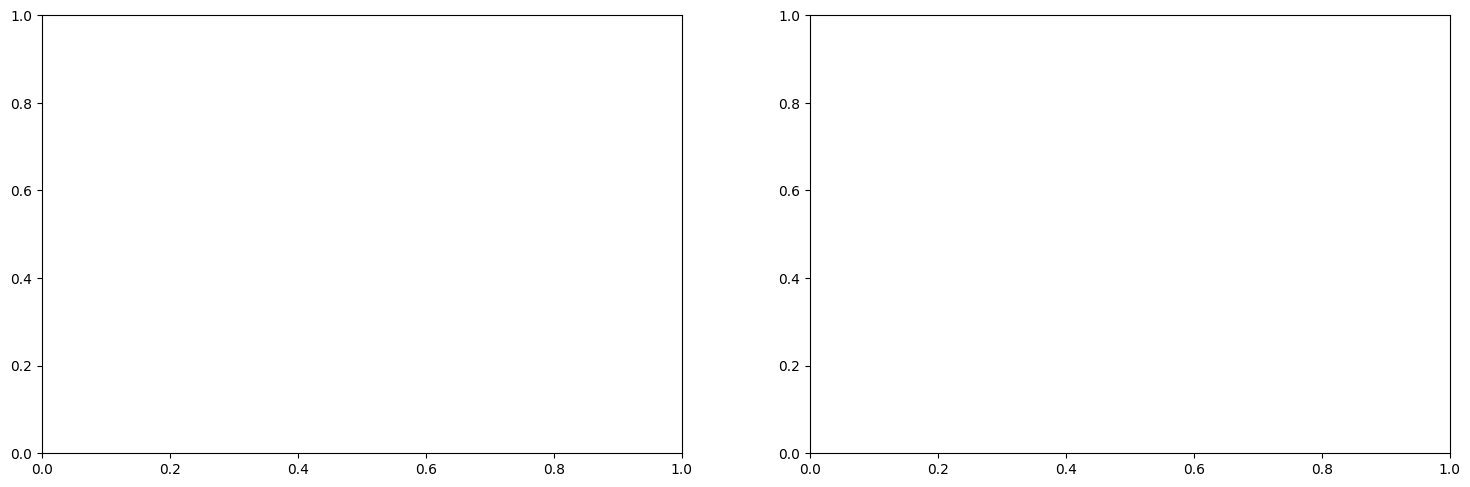

In [9]:
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec

plot_all = False
plot_sampling = True
plot_proposals = True
plot_cpc_search = True

num_frames = selected_beta_idx + 20 if plot_cpc_search else 20
num_frames += n_AR_rounds if plot_sampling else 0
num_frames = int(num_frames)
print(f"num_frames : {num_frames}")
# int(selected_beta_idx + n_AR_rounds) if plot_sampling else selected_beta_idx + 20


figw, figh = 16.0, 6.0

if plot_all:
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(figw, figh))
    # fig = plt.figure(figsize=(13, 16))
    fig = plt.figure(figsize=(16, 11))
    # gs = fig.add_gridspec(3, 2)
    gs = GridSpec(2, 2, height_ratios=[1, 2])
    fig.subplots_adjust(left=0.07,
                        right=0.95, 
                        bottom=0.15,
                        hspace=0.2,
                        wspace=0.2
                       )

    ax1 = fig.add_subplot(gs[1, 0])
    ax2 = fig.add_subplot(gs[1, 1])

    ax_title = fig.add_subplot(gs[0, :])
    ax_title.set_xticks([])
    ax_title.set_yticks([])
    ax_title.axis('off')
    img = mpimg.imread('animation_cpc_title.png')
    ax_title.imshow(img)


elif plot_cpc_search:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(figw, figh))
    fig.subplots_adjust(left=0.07, 
                    right=0.95, 
                    bottom=0.15)

    
else:
    fig, ax2 = plt.subplots(1, 1, figsize=(figw/2, figh))
    fig.subplots_adjust(left=0.12, 
                    right=0.95, 
                    bottom=0.15)




In [ ]:
# 1. Define the init function
def init():
    line, = ax1.plot([], [])
    line.set_data([], [])
    return line,  # Returns the artist to be redrawn


def update_frame(i):
    global selected_beta_idx
    global selected_beta
    global alpha
    global n_target
    global accepted_samples
    global n_AR_rounds
    global plot_sampling

    

    if i % 20 == 0:
        print(f"i : {i}, progress : {i/num_frames*100}%")

    # print(f"i : {i}")
    plt.cla()
    if plot_cpc_search:
        ax1.clear()
        ax2.clear()
    else:
        ax2.clear()

    
    
    if i < len(betas) and plot_cpc_search:
        beta = betas[i]
    else:
        beta = selected_beta


        
    if not plot_cpc_search or w_emp_risk_all[min(i, len(w_emp_risk_all)-1)] > alpha:
        beta = selected_beta
        betas_curr = np.array([None, selected_beta])
        idx = selected_beta_idx

    else:
        idx = i
        betas_curr = np.array([None, beta])
    pdf1_constrained_values = np.where(
        lik_ratios < beta, pdf1_values, beta * pdf0_values
    )

    norm_const = (
        (
            np.sum(pdf1_constrained_values)
            * (np.max(x_values) - np.min(x_values))
            / len(x_values)
        )
        if beta < np.inf
        else 1.0
    )



    liks_mat = np.vstack((pdf0_values, pdf1_values))


    constrained_policy_transparency = 0.75 if beta < selected_beta else 1.0
    constrained_policy_label = "Constrained Policy (Candidate)" if beta < selected_beta else "Constrained Policy (Selected)"

    if plot_cpc_search:
        ax1.plot(betas[:idx+1], w_emp_risk_all[:idx+1], label="Empirical Risk", color=BLUE, 
                linewidth=4, linestyle="-", alpha=0.75, marker='o', markersize=4)
        # ax1_emp_risk.set_data(betas[:idx+1], w_emp_risk_all[:idx+1])
        ax1.scatter(betas[idx], w_emp_risk_all[idx], label="Current Empirical Risk", color=BLUE, 
                linewidth=4, linestyle="-", alpha=constrained_policy_transparency, marker='o', s=16)
        # ax1_curr_emp_risk.set_data(betas[idx], w_emp_risk_all[idx])
        ax1.fill_between(betas[:idx+1], w_emp_risk_cal_list[:idx+1], w_emp_risk_all[:idx+1], color=RED, alpha=0.3, label="Weighted Conservative Adjustment")
        # ax1_test_risk.set_data(betas[:idx+1], w_emp_risk_cal_list[:idx+1], w_emp_risk_all[:idx+1])
        ax1.fill_between(betas[:idx+1], np.zeros(idx+1), w_emp_risk_cal_list[:idx+1], color=TEAL, alpha=0.3, label="Calibration Set Risk")
        # ax1_cal_risk.set_data(betas[:idx+1], np.zeros(idx+1), w_emp_risk_cal_list[:idx+1])

        ax1.axhline(alpha, color='darkred', linestyle='--', alpha=0.5, linewidth=3, label=r'$\alpha$ (Risk Tolerance)')
        
        ax1.axvline(betas[0], color=BLUE, linestyle='-', alpha=0.5, linewidth=3)

        # ax1_curr_beta_line.set_data(beta)

        # ax1.set_xscale('log')
        ax1.set_xlabel(r"$\beta$ (Control Parameter)", fontsize=24)
        ax1.set_ylabel(r"Empirical Risk [$\leftarrow$]", fontsize=24)
        ax1.tick_params(labelsize=16)
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='best', fontsize=14)
        ax1.set_title(r"CPC $\beta$ Search", fontsize=18)
        ax1.set_ylim([0.18, 0.75])
        
        # Set consistent x-axis limits for right plot
        ax1.set_xlim([betas[0], betas[-1]])


    psis_curr = np.array([None, norm_const])
    constrained_liks = constrain_likelihoods(liks_mat, betas_curr, psis_curr)
    pdf1_constrained_values_normalized = constrained_liks[-1]


    # Left subplot: Policy distributions
    ax2.plot(x_values, pdf0_values, label="Safe Policy", color=TEAL, linewidth=4, 
            linestyle="--", alpha=0.75, zorder=1)
    ax2.plot(
        x_values, pdf1_values, label="Optimized Policy", color=RED, linewidth=4, 
        linestyle=":", alpha=0.75, zorder=2
    )
    
    ax2.plot(
        x_values,
        pdf1_constrained_values_normalized,
        label=constrained_policy_label,
        color=BLUE,
        alpha=constrained_policy_transparency,
        linewidth=4, zorder=3
    )

    

    if not plot_cpc_search or w_emp_risk_all[min(i, len(w_emp_risk_all)-1)] > alpha and plot_sampling:
        
        if plot_proposals:

            # n_proposals = len(proposal_samples)
            n_bins = 100
            hist_range = np.max(proposal_samples) - np.min(proposal_samples)
            if plot_cpc_search:
                curr_len = int(min((i-selected_beta_idx+1)*n_AR_rounds, len(proposal_samples)))
            else:
                curr_len = int(min((i+1) * n_target / n_AR_rounds, len(proposal_samples)))
            

            weights = n_bins / hist_range * np.ones(curr_len) * (len(proposal_samples) / n_target) / curr_len


            ax2.hist(np.array(proposal_samples[:curr_len]), 
                 bins=n_bins, 
                 alpha=0.5, 
                 color=RED if selected_beta >= 1.0 else TEAL, 
                 label="Proposed Samples",
                 weights=weights,
                 zorder=4)
                 
        if plot_cpc_search:
            curr_len_accepted = int(min((i-selected_beta_idx+1)*n_AR_rounds * n_target / len(proposal_samples), len(accepted_samples)))

        else:
            curr_len_accepted = int(min((i+1)*n_AR_rounds * n_target / len(proposal_samples), len(accepted_samples)))

        ax2.hist(np.array(accepted_samples[:curr_len_accepted]), 
            bins=100, 
            alpha=0.5, 
            color=BLUE, 
            label="Accepted Samples",
            density=True,
            zorder=5
        )



    ax2.set_xlabel("Action Space", fontsize=24)
    ax2.set_ylabel("Density", fontsize=24)
    ax2.tick_params(labelsize=16)
    ax2.set_ylim([0, 0.7])
    ax2.legend(loc='upper left', fontsize=14)
    if beta < selected_beta and plot_cpc_search:
        ax2.set_title(r"Constrained Policy Exploration, $\beta$ " + f"= {beta:.2e}", fontsize=18)
    else:
        ax2.set_title(r"Constrained Policy Sampling, $\hat\beta$ " + f"= {beta:.2e}", fontsize=18)

    
# Create the animation
print(num_frames)
anim = animation.FuncAnimation(fig, update_frame,
                               init_func=init,
                               frames=num_frames, 
                               interval=500, 
                               repeat=True, 
                               repeat_delay=3000)

anim.save(f'Animation_alpha{alpha}_betaHat{selected_beta:2f}_CPCsearch{plot_cpc_search}_sampling{plot_sampling}_proposals{plot_proposals}.gif', 
          writer='ffmpeg', 
          fps=10, 
          dpi=300)



MovieWriter ffmpeg unavailable; using Pillow instead.


115
i : 0, progress : 0.0%
